# Retail Sales Analysis — Superstore Dataset

### Objective
This project explores a retail superstore's order-level sales data to answer a structured set of business questions — from basic sales metrics to regional, customer, and time-based patterns — using Pandas, NumPy, and Matplotlib.

### Dataset Overview
- **Rows:** 9,800 order line items
- **Columns:** 18 (order details, customer info, product info, geography, and sales value)
- **Key fields used:** `Order ID`, `Customer ID`/`Customer Name`, `Segment`, `Region`, `State`, `Category`, `Sub-Category`, `Product Name`, `Order Date`, `Sales`

### Structure of this Notebook
1. Data Loading & Understanding
2. Basic Sales & Order Metrics
3. Category & Sub-Category Analysis
4. Product Analysis
5. Concentration & Risk Analysis
6. Customer Segmentation
7. Regional Analysis
8. Time-Based Analysis
9. Multi-Dimensional Insights
10. Business Recommendations
11. Key Business Findings
12. Conclusion

## 1. Data Loading & Understanding

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("train.csv")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.shape

(9800, 18)

No missing values were found in any column of the dataset.

In [7]:
df.isna().sum().sum()

np.int64(11)

## 2. Basic Sales & Order Metrics
*(Questions 1–6)*

**Question 1: How many unique orders are there?**

In [8]:
df["Order ID"].nunique()

4922

*Note: this was cross-checked with `value_counts().count()`, `drop_duplicates().count()`, and `len(unique())` — all four approaches returned the same result (4,922).*

**Question 2: How many unique customers are there?**

In [9]:
df["Customer ID"].nunique()

793

**Question 3–6: Total sales, and average / median / mode order value**

In [10]:
total = df["Sales"].sum()
total

np.float64(2261536.7827)

*This total is cross-verified below in the Category and Regional sections — the sales summed by Category, by Region, and by Year all independently total to the same ₹2,261,536.78.*

In [11]:
order_totals = df.groupby("Order ID")["Sales"].sum()
order_totals.mean(), order_totals.median(), order_totals.mode()[0]

(np.float64(459.4751691791955), np.float64(151.875), np.float64(12.96))

In [12]:
order_totals.mean()

np.float64(459.4751691791955)

In [13]:
order_totals.median()

np.float64(151.875)

In [14]:
order_totals.mode()

0    12.96
Name: Sales, dtype: float64

**Finding:** Order values are highly uneven — the mean order value (₹459.48) is roughly three times the median (₹151.88), and the single most common order value is only ₹12.96. A small number of high-value orders are pulling the average well above the typical order.

## 3. Category & Sub-Category Analysis
*(Questions 7–10)*

**Question 7 & 8: Which category generates the most sales, and what % does each contribute?**

In [15]:
category_sales = df.groupby("Category")["Sales"].sum()
category_sales

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

In [16]:
category_contribution = category_sales / total * 100
category_contribution

Category
Furniture          32.219621
Office Supplies    31.192167
Technology         36.588212
Name: Sales, dtype: float64

**Finding:** Technology is the largest category, generating approximately ₹827,456 in sales (36.59% of total), compared with Furniture (₹728,659, 32.22%) and Office Supplies (₹705,422, 31.19%). Sales are relatively diversified across the three categories rather than heavily dependent on one.

**Question 9 & 10: Which sub-category generates the most / least sales?**

In [17]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
subcategory_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

**Finding:** Phones is the highest-selling sub-category (₹327,782.45), narrowly ahead of Chairs (₹322,822.73). Fasteners is the lowest-selling sub-category (₹3,001.96).

## 4. Product Analysis
*(Questions 11–12)*

**Question 11 & 12: Top 10 products by sales, and their % of total sales**

In [18]:
top_10_products = df.groupby("Product Name")["Sales"].sum().nlargest(10)
top_10_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

**[INCOMPLETE]** The individual top-10 product names/values were computed (`nlargest(10)`) but the result was never printed in the original notebook, so the specific product list can't be reproduced here without re-running against the source CSV. Re-run this cell against `train.csv` to see the list.

In [19]:
top_10_products.sum() / total * 100

np.float64(10.816547662247316)

**Finding:** The top 10 products contribute only 10.82% of total sales, indicating sales are spread across the product portfolio rather than concentrated in a handful of items.

## 5. Concentration Analysis
*(Questions 13–16)*

These questions test how dependent the business is on a small number of customers or sub-categories.

**Question 13: What % of total sales comes from the top 10 customers?**

In [20]:
top_10_customers_sales = df.groupby("Customer Name")["Sales"].sum().nlargest(10)
top_10_customers_sales.sum() / total * 100

np.float64(6.8011791882672)

**Question 14: How many customers are needed to reach 50% of total sales?**

In [21]:
customer_sales_sorted = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)
cumulative_customer_sales = customer_sales_sorted.cumsum()
threshold_50 = 0.5 * total
reached_50 = cumulative_customer_sales >= threshold_50
reached_50.values.argmax() + 1  # number of customers needed

np.int64(168)

**Question 15: What % of total sales comes from the top 5 sub-categories?**

In [22]:
top_5_subcategories = df.groupby("Sub-Category")["Sales"].sum().nlargest(5)
top_5_subcategories.sum() / total * 100

np.float64(56.27978256804852)

**Question 16: Which sub-categories contribute less than 2% of total sales?**

In [23]:
threshold_2pct = 0.02 * total
subcategory_sales_raw = df.groupby("Sub-Category")["Sales"].sum()
subcategory_sales_raw[subcategory_sales_raw < threshold_2pct]

Sub-Category
Art          26705.410
Envelopes    16128.046
Fasteners     3001.960
Labels       12347.726
Name: Sales, dtype: float64

**Finding:** Customer revenue is relatively well distributed — the top 10 customers account for only 6.80% of total sales, and it takes 168 customers to reach 50% of revenue. By contrast, sub-category sales are more concentrated: the top 5 sub-categories already make up 56.28% of total sales, while Art, Envelopes, Fasteners, and Labels each contribute less than 2%.

## 6. Customer Segmentation
*(Questions 17–19)*

**Question 17: How much does each customer segment contribute to total sales?**

In [24]:
segment_sales = df.groupby("Segment")["Sales"].sum()
segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

In [25]:
segment_sales / total * 100

Segment
Consumer       50.764619
Corporate      30.443638
Home Office    18.791743
Name: Sales, dtype: float64

**Question 18: Which customer segment has the highest average order value?**

In [26]:
order_segment_sales = df.groupby(["Order ID", "Segment"])["Sales"].sum()
avg_order_value_by_segment = order_segment_sales.groupby(level="Segment").mean()
avg_order_value_by_segment

Segment
Consumer       452.526816
Corporate      461.766650
Home Office    475.371563
Name: Sales, dtype: float64

**Question 19: Which customer segment is most important to the business?**

**Finding:** Consumer is the most important segment by revenue, contributing 50.76% of total sales — roughly half of company revenue. Home Office has the highest average order value (₹475.37), followed by Corporate (₹461.77) and Consumer (₹452.53), so while Consumer drives the most volume, Home Office orders tend to be slightly larger on average.

## 7. Regional Analysis
*(Questions 20–24)*

**Question 20 & 22: Sales by region, and % of total sales per region**

In [27]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

In [28]:
region_sales / total * 100

Region
West       31.404295
East       29.604591
Central    21.783723
South      17.207390
Name: Sales, dtype: float64

**Finding:** West generates the highest total sales (₹710,219.68, 31.40%), followed by East (₹669,518.73, 29.60%), Central (₹492,646.91, 21.78%), and South (₹389,151.46, 17.21%), which is the lowest-performing region.

**Question 21: What are the top 5 and bottom 5 states by sales?**

In [29]:
state_sales = df.groupby("State")["Sales"].sum()
state_sales.nlargest(5)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Name: Sales, dtype: float64

In [30]:
state_sales.nsmallest(5)

State
North Dakota      919.910
West Virginia    1209.824
Maine            1270.530
South Dakota     1315.560
Wyoming          1603.136
Name: Sales, dtype: float64

**Question 23: How many states are needed to reach 50% of total sales?**

In [31]:
state_sales_sorted = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
cumulative_state_sales = state_sales_sorted.cumsum()
states_reached_50 = cumulative_state_sales >= (0.5 * total)
states_reached_50.values.argmax() + 1

np.int64(5)

**Question 24: Which states perform way above or below average?**

In [32]:
average_state_sales = state_sales.mean()
states_way_above_average = state_sales[state_sales > 1.5 * average_state_sales]
states_way_below_average = state_sales[state_sales < 0.5 * average_state_sales]
states_way_below_average

State
Alabama                 19510.640
Arkansas                11678.130
Connecticut             13384.357
District of Columbia     2865.020
Idaho                    4382.486
Iowa                     4443.560
Kansas                   2914.310
Louisiana                9131.050
Maine                    1270.530
Mississippi             10771.340
Missouri                22205.150
Montana                  5589.352
Nebraska                 7464.930
Nevada                  16729.102
New Hampshire            7292.524
New Mexico               4783.522
North Dakota              919.910
Oklahoma                19683.390
Oregon                  17284.462
Rhode Island            22525.026
South Carolina           8481.710
South Dakota             1315.560
Utah                    11220.056
Vermont                  8929.370
West Virginia            1209.824
Wyoming                  1603.136
Name: Sales, dtype: float64

**[INCOMPLETE]** `states_way_above_average` was computed with the same logic in the original notebook but its output was never printed, so the specific list of above-average outlier states isn't available here without re-running against the source data. The below-average list (26 states, mostly lower-population states) is preserved above.

**Finding:** Sales are geographically concentrated at the state level — just 5 states account for 50% of total sales, and 26 states fall well below the average state sales figure.

## 8. Time-Based Analysis
*(Questions 25–30)*

In [33]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

**Question 25: Total sales per year — which year performed best?**

In [34]:
yearly_sales = df.groupby("Year")["Sales"].sum()
yearly_sales

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

*(Computed directly from the monthly-by-year breakdown shown in Question 27 below; not printed separately in the original notebook.)*

**Finding:** 2018 recorded the highest total sales (₹722,052.02) among the four years in the dataset.

**Question 26: Average sales per month across all years — which month performs best?**

In [35]:
monthly_yearly_sales = df.groupby(["Month", "Year"])["Sales"].sum()
monthly_average = monthly_yearly_sales.groupby(level="Month").mean()
monthly_average

Month
1     23572.907400
2     14842.778850
3     49393.396800
4     34070.750150
5     38521.680925
6     36459.380825
7     36383.922250
8     39328.981750
9     75025.852925
10    49874.073675
11    87540.427750
12    80370.042375
Name: Sales, dtype: float64

**Finding:** November has the highest average monthly sales.

**Question 27: Do specific months consistently perform high or low across years?**

In [36]:
monthly_yearly_sales

Month  Year
1      2015     14205.7070
       2016     18066.9576
       2017     18542.4910
       2018     43476.4740
2      2015      4519.8920
       2016     11951.4110
       2017     22978.8150
       2018     19920.9974
3      2015     55205.7970
       2016     32339.3184
       2017     51165.0590
       2018     58863.4128
4      2015     27906.8550
       2016     34154.4685
       2017     38679.7670
       2018     35541.9101
5      2015     23644.3030
       2016     29959.5305
       2017     56656.9080
       2018     43825.9822
6      2015     34322.9356
       2016     23599.3740
       2017     39724.4860
       2018     48190.7277
7      2015     33781.5430
       2016     28608.2590
       2017     38320.7830
       2018     44825.1040
8      2015     27117.5365
       2016     36818.3422
       2017     30542.2003
       2018     62837.8480
9      2015     81623.5268
       2016     63133.6060
       2017     69193.3909
       2018     86152.8880
10     2015     

**Finding:** February consistently records relatively low sales, while September, November, and December consistently record relatively high sales across all four years.

**Question 28: What is the % difference between the best and worst month?**

In [37]:
peak_month = monthly_average.loc[11]  # November
low_month = monthly_average.loc[2]    # February
(peak_month - low_month) / low_month * 100

np.float64(489.78462614498903)

**Question 29: Is overall sales increasing, decreasing, or flat over time?**

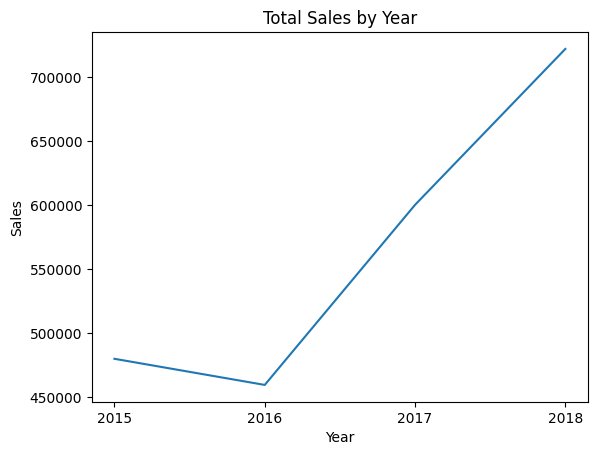

In [38]:
plt.plot(yearly_sales.index, yearly_sales)
plt.xticks(yearly_sales.index)
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

**Finding:** Overall sales show an increasing trend from 2015 to 2018, although sales dipped slightly in 2016 compared with 2015.

**Question 30: Are there unusual spikes or dips in specific months?**

In [39]:
monthly_yearly_sales.mean(), monthly_yearly_sales.std()

(np.float64(47115.34963958334), np.float64(24978.687304552535))

In [40]:
monthly_yearly_sales.mean()

np.float64(47115.34963958334)

In [41]:
monthly_yearly_sales.std()

np.float64(24978.687304552535)

In [42]:
upper_limit = monthly_yearly_sales.mean() + 2 * monthly_yearly_sales.std()
lower_limit = monthly_yearly_sales.mean() - 2 * monthly_yearly_sales.std()
lower_limit, upper_limit

(np.float64(-2842.024969521728), np.float64(97072.7242486884))

In [43]:
lower_limit

np.float64(-2842.024969521728)

In [44]:
upper_limit

np.float64(97072.7242486884)

In [45]:
monthly_yearly_sales[monthly_yearly_sales > upper_limit]

Month  Year
11     2018    117938.155
Name: Sales, dtype: float64

No months fell below the lower threshold.

**Drilling into the November 2018 spike:**

In [46]:
nov_2018 = df[(df["Month"] == 11) & (df["Year"] == 2018)]
nov_2018.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         49409.103
Furniture          37056.715
Office Supplies    31472.337
Name: Sales, dtype: float64

In [47]:
nov_2018.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
East       45633.639
West       28718.207
South      28431.331
Central    15154.978
Name: Sales, dtype: float64

In [48]:
nov_2018[nov_2018["Region"] == "East"].groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         22584.223
Office Supplies    12166.422
Furniture          10882.994
Name: Sales, dtype: float64

**WHAT:** November 2018 recorded an unusually high sales spike of ₹117,938.16, exceeding the 2-standard-deviation upper limit of ₹97,072.72. No unusually low months were identified. The spike was led by the East region (₹45,633.64 of the month's sales), where Technology alone contributed ₹22,584.22.

**SO WHAT:** A single month can materially skew monthly performance comparisons if not accounted for.

**NOW WHAT:** The exact cause (promotion, large one-off order, seasonal event) can't be determined from the sales data alone and would need to be checked against order-level detail or business records. **[VERIFY]**

## 9. Multi-Dimensional Insights
*(Questions 31–34)*

**Question 31: For each category, which month has the highest sales?**

In [49]:
category_month_sales = df.groupby(["Category", "Month"])["Sales"].sum()
category_month_sales.groupby(level="Category").idxmax()

Category
Furniture               (Furniture, 12)
Office Supplies    (Office Supplies, 9)
Technology             (Technology, 11)
Name: Sales, dtype: object

In [50]:
category_month_sales.groupby(level="Category").max()

Category
Furniture          121462.0255
Office Supplies    101075.2780
Technology         130497.1870
Name: Sales, dtype: float64

**Finding:** Each category peaks in a different month — Furniture in December (₹121,462.03), Office Supplies in September (₹101,075.28), and Technology in November (₹130,497.19), which is also the highest single peak value of the three.

**Question 32: For each region, which category has the highest sales?**

In [51]:
region_category_sales = df.groupby(["Region", "Category"])["Sales"].sum()
region_category_sales.groupby(level="Region").idxmax()

Region
Central    (Central, Technology)
East          (East, Technology)
South        (South, Technology)
West          (West, Technology)
Name: Sales, dtype: object

In [52]:
region_category_sales.groupby(level="Region").max()

Region
Central    168739.208
East       263116.527
South      148195.208
West       247404.930
Name: Sales, dtype: float64

**Finding:** Technology is the highest-selling category in all four regions, with the largest Technology sales coming from the East region (₹263,116.53).

**Question 33: For each segment, which category has the highest sales?**

In [53]:
segment_category_sales = df.groupby(["Segment", "Category"])["Sales"].sum()
segment_category_sales.groupby(level="Segment").idxmax()

Segment
Consumer          (Consumer, Technology)
Corporate        (Corporate, Technology)
Home Office    (Home Office, Technology)
Name: Sales, dtype: object

In [54]:
segment_category_sales.groupby(level="Segment").max()

Segment
Consumer       401011.665
Corporate      244041.837
Home Office    182402.371
Name: Sales, dtype: float64

**Finding:** Technology is the highest-selling category across all three customer segments, with Consumer generating the highest Technology sales (₹401,011.67).

**Question 34: Which region/segment/category do the top 10% of customers belong to?**

In [55]:
customer_sales_by_id = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False)
# 793 total customers -> top 10% ~ 79-80 customers
top_10pct_customers = customer_sales_by_id.head(80)
high_value_customers = df[df["Customer ID"].isin(top_10pct_customers.index)]

In [56]:
high_value_customers.groupby("Segment")["Customer ID"].nunique()

Segment
Consumer       40
Corporate      26
Home Office    14
Name: Customer ID, dtype: int64

In [57]:
high_value_customers.groupby("Category")["Customer ID"].nunique()

Category
Furniture          77
Office Supplies    80
Technology         79
Name: Customer ID, dtype: int64

**Finding:** Among the top 10% of customers (80 customers), Consumer is the largest segment (40 customers, 50%). Office Supplies was purchased by all 80 high-value customers, followed by Technology (79) and Furniture (77). These customers also span multiple regions, so regional counts overlap and aren't mutually exclusive.

## 10. Business Recommendations
*(Questions 35–36)*

**Question 35: Concentration risk — if the top 10 customers leave, what % of revenue is lost?**

In [58]:
top_10_customer_sales = customer_sales_by_id.head(10)
top_10_customer_sales.sum()

np.float64(153811.16900000002)

In [59]:
top_10_customer_sales.sum() / total * 100

np.float64(6.8011791882672)

**WHAT:** Losing the 10 highest-spending customers would cost about 6.80% of total sales.

**SO WHAT:** This is a relatively low concentration risk — the business is not heavily dependent on a small handful of customers.

**NOW WHAT:** Customer retention efforts can reasonably stay broad-based rather than being narrowly focused on a small VIP list.

**Question 36: Growth opportunity — which underperforming category/region has potential?**

In [60]:
south_category_sales = df[df["Region"] == "South"].groupby("Category")["Sales"].sum().sort_values()
south_total_sales = south_category_sales.sum()
south_category_sales / south_total_sales * 100

Category
Furniture          29.945019
Office Supplies    31.973353
Technology         38.081627
Name: Sales, dtype: float64

In [61]:
south_total_sales / total * 100

np.float64(17.207390212570434)

**WHAT:** South is the lowest-performing region, generating ₹389,151.46 (17.21% of total sales), and it underperforms the other three regions across all three categories.

**SO WHAT:** South represents the region with the most headroom relative to the other three regions.

**NOW WHAT:** South could reasonably be investigated further (e.g. store/rep coverage, marketing spend, local competition) to understand why it lags. **[VERIFY]** — the sales data alone doesn't explain the cause, only the size of the gap.

## 11. Key Business Findings
*(Question 37 — what should management know?)*

1. **Technology is the strongest revenue category.** It generates the highest overall sales at ₹827,455.87 (36.59% of total sales) and is the top-selling category across all four regions and all three customer segments.
2. **South is the weakest-performing region.** It generates ₹389,151.46 (17.21% of total sales) and has the lowest sales within each category compared with the other regions.
3. **Customer revenue is relatively well distributed.** The top 10 customers contribute only 6.80% of total sales, so the business is not heavily dependent on a small number of customers.
4. **Category demand peaks at different times.** Furniture peaks in December (₹121,462.03), Office Supplies in September (₹101,075.28), and Technology in November (₹130,497.19).
5. **November 2018 was an unusually strong month**, recording ₹117,938.16 — above the upper anomaly threshold of ₹97,072.72 — driven largely by the East region and the Technology category.

# 12. Business Visualizations

The following visualizations summarize the major findings from the analysis and provide a visual representation of sales performance across categories, regions, products, customers, and time.

In [2]:
# ============================================================
# BUSINESS VISUALIZATIONS
# ============================================================

import os
import matplotlib.pyplot as plt

# Folder for GitHub-ready chart images
os.makedirs("visualizations", exist_ok=True)

## 12.1 Annual Sales Trend

This visualization shows how total sales changed across the years in the dataset.

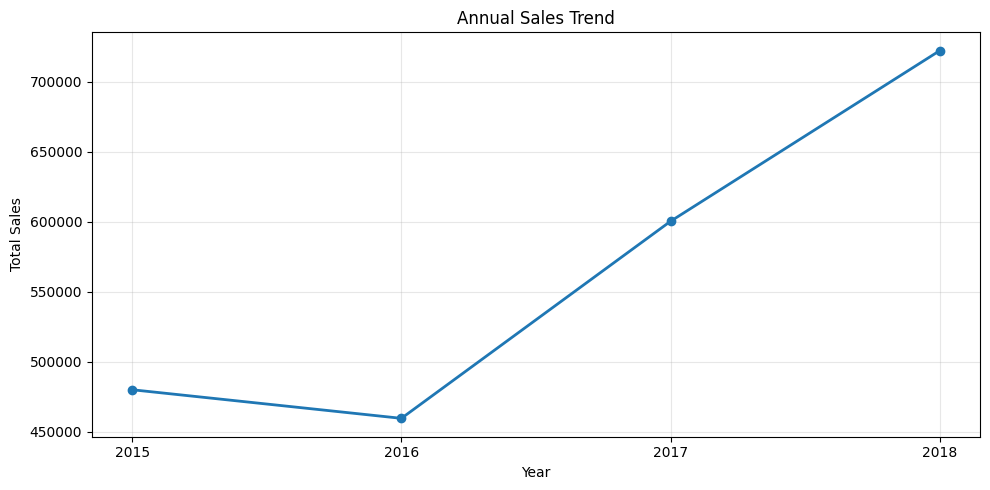

In [62]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Annual Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(yearly_sales.index)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "visualizations/annual_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12.2 Category Performance

This chart compares total sales across the three major product categories.

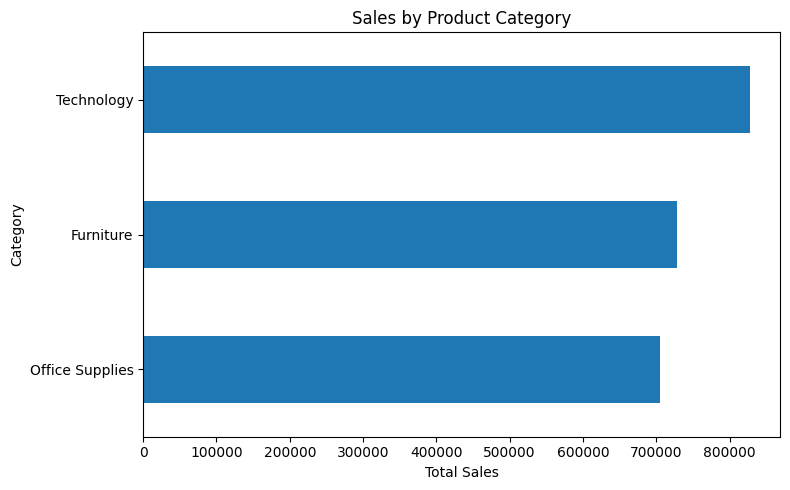

In [63]:
plt.figure(figsize=(8, 5))

category_sales.sort_values().plot(
    kind="barh"
)

plt.title("Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "visualizations/category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Business Insight:** Technology generates the highest total sales among the three categories.

## 12.3 Regional Sales Performance

This visualization compares total sales across the four regions.

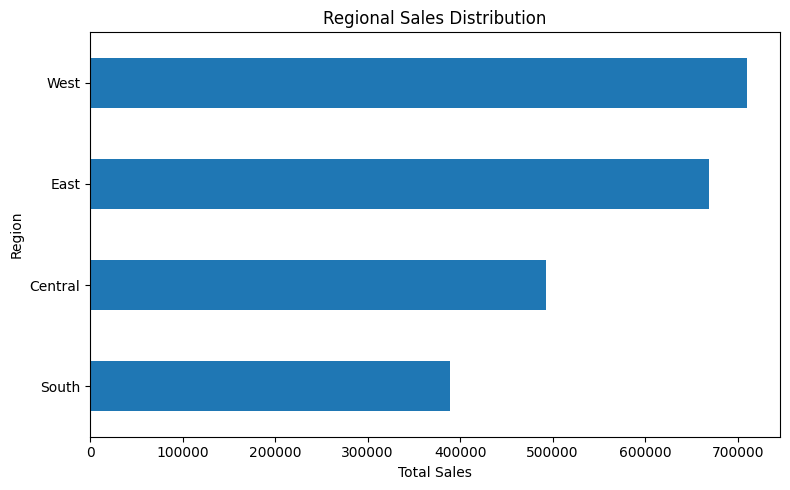

In [64]:
plt.figure(figsize=(8, 5))

region_sales.sort_values().plot(
    kind="barh"
)

plt.title("Regional Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    "visualizations/regional_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Business Insight:** West is the highest-sales region, while South has the lowest total sales.

## 12.4 Category Performance Across Regions

This visualization examines whether category performance changes across geographic regions.

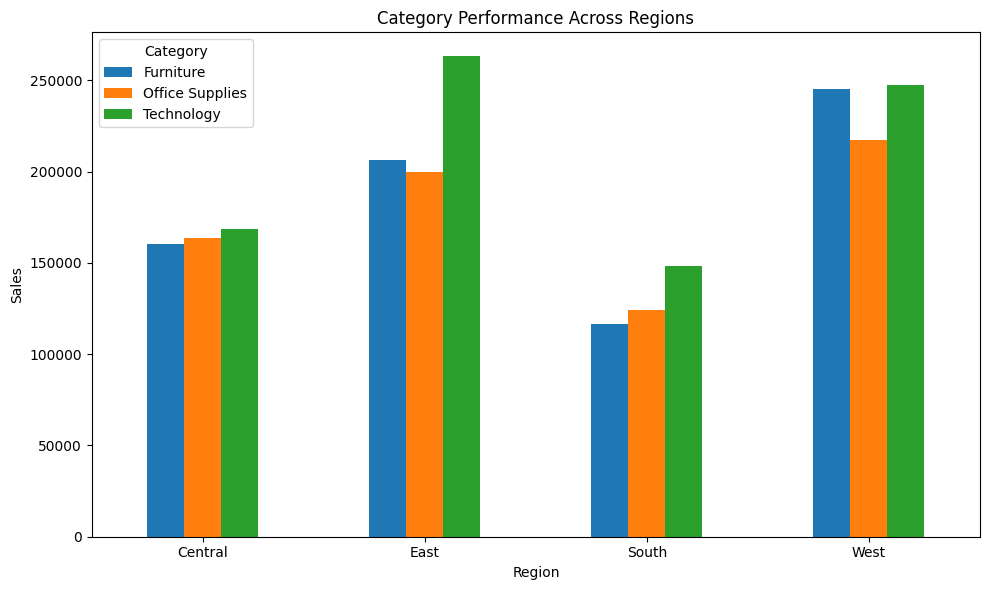

In [65]:
region_category_plot = (
    df.groupby(["Region", "Category"])["Sales"]
    .sum()
    .unstack()
)

region_category_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Category Performance Across Regions")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.legend(title="Category")

plt.tight_layout()

plt.savefig(
    "visualizations/region_category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Business Insight:** Technology is the highest-selling category across all four regions.

## 12.5 Monthly Sales Seasonality

This chart shows the average sales for each month across all years, helping identify recurring seasonal patterns.

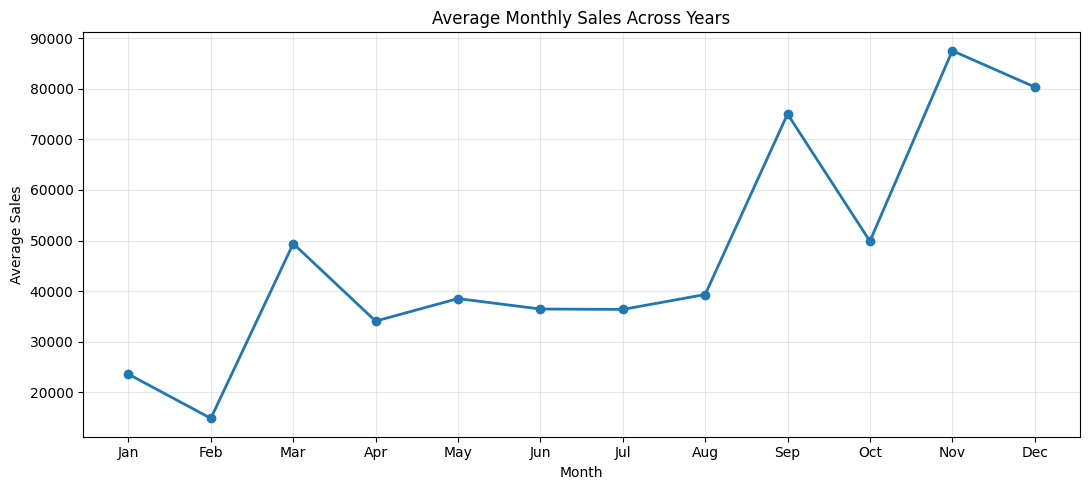

In [66]:
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(11, 5))

plt.plot(
    month_names,
    monthly_average.values,
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Sales Across Years")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "visualizations/monthly_sales_seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Business Insight:** Sales show clear seasonality, with November among the strongest months and February among the weakest.

## 12.6 Monthly Sales Trends Across Years

This visualization compares monthly sales patterns across different years to identify recurring seasonal behavior and year-to-year variation.

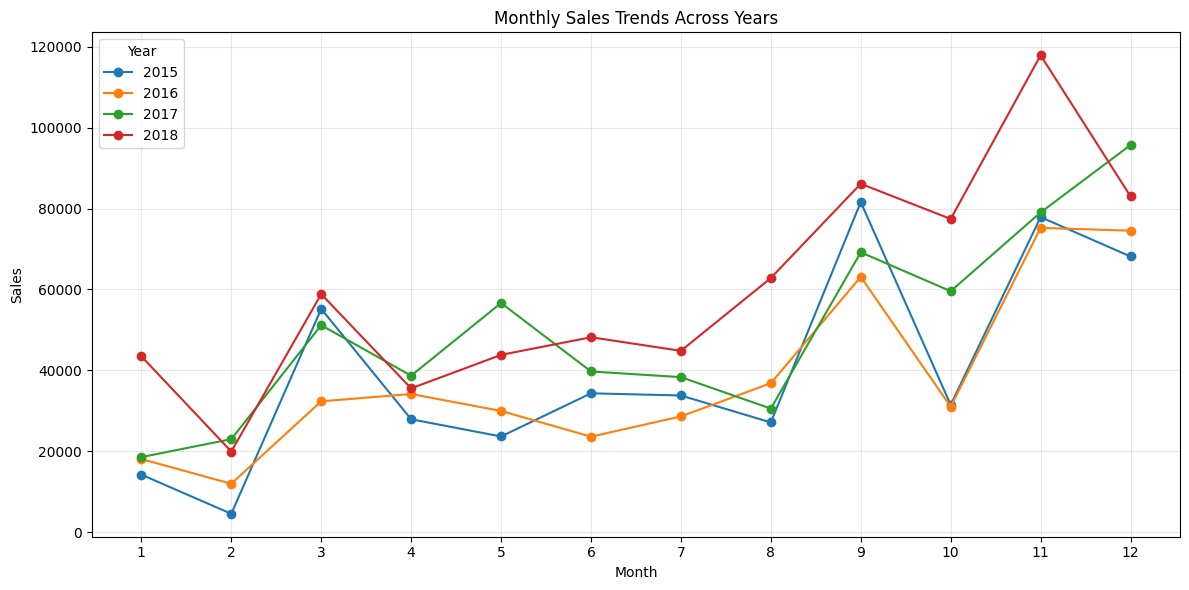

In [67]:
monthly_yearly_plot = (
    monthly_yearly_sales
    .unstack(level="Year")
)

monthly_yearly_plot.plot(
    figsize=(12, 6),
    marker="o"
)

plt.title("Monthly Sales Trends Across Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.legend(title="Year")

plt.tight_layout()

plt.savefig(
    "visualizations/monthly_sales_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Business Insight:** Comparing monthly sales across years helps distinguish recurring seasonal patterns from individual-year fluctuations.

## 12.7 Top 10 Products by Sales

This visualization identifies the products contributing the highest individual sales totals.

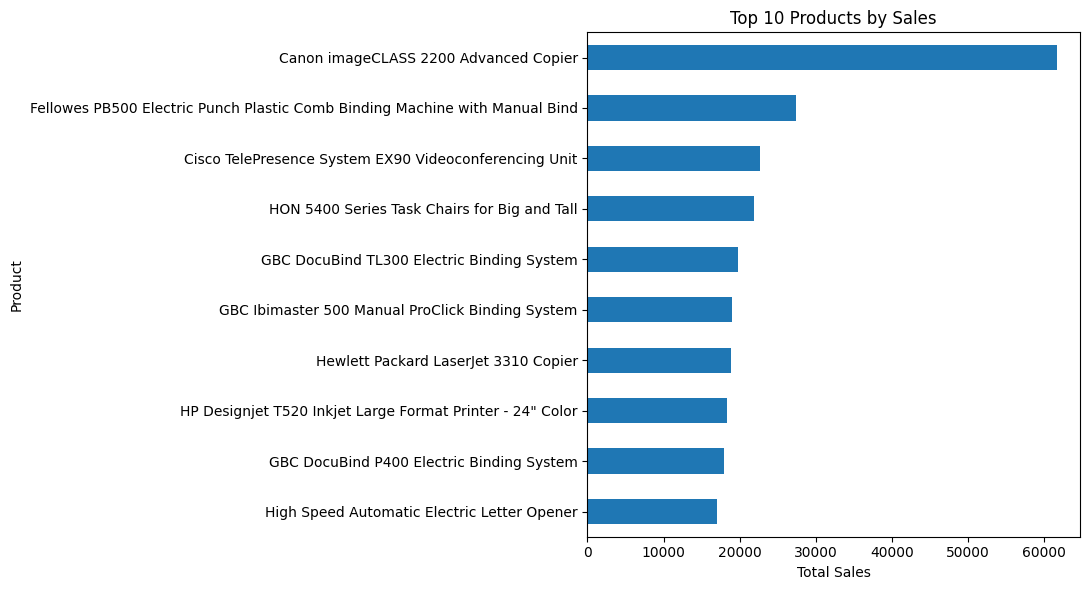

In [68]:
top_10_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(11, 6))

top_10_products.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "visualizations/top_10_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:
top_10_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

## 12.8 Customer Sales Concentration

This visualization shows how quickly cumulative sales increase as customers are ranked from highest to lowest sales contribution.

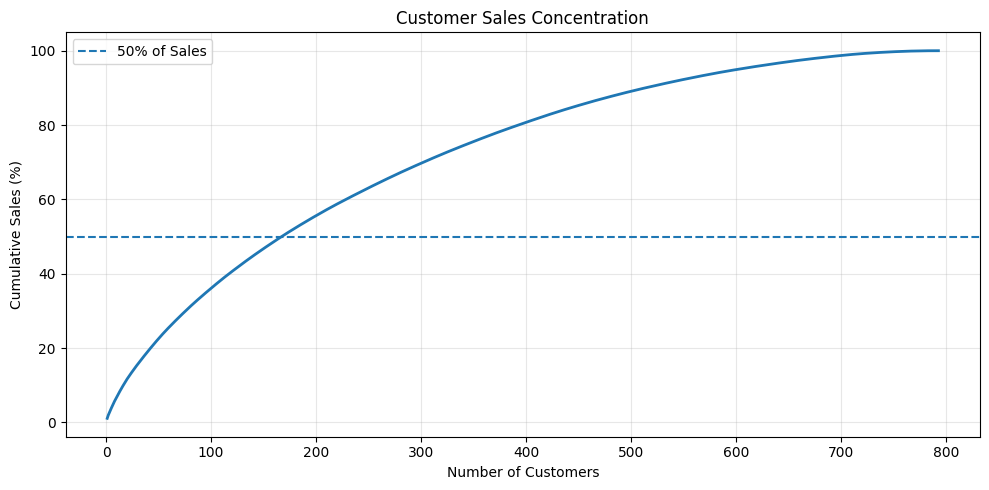

In [70]:
customer_sales_sorted = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

cumulative_customer_sales = customer_sales_sorted.cumsum()

cumulative_percentage = (
    cumulative_customer_sales / total * 100
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_percentage) + 1),
    cumulative_percentage,
    linewidth=2
)

plt.axhline(
    50,
    linestyle="--",
    linewidth=1.5,
    label="50% of Sales"
)

plt.title("Customer Sales Concentration")
plt.xlabel("Number of Customers")
plt.ylabel("Cumulative Sales (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "visualizations/customer_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Business Insight:** The top 10 customers account for approximately 6.80% of total sales, indicating that revenue is distributed across a relatively broad customer base.

## 12.9 Geographic Sales Concentration

This chart highlights the ten states generating the highest total sales.

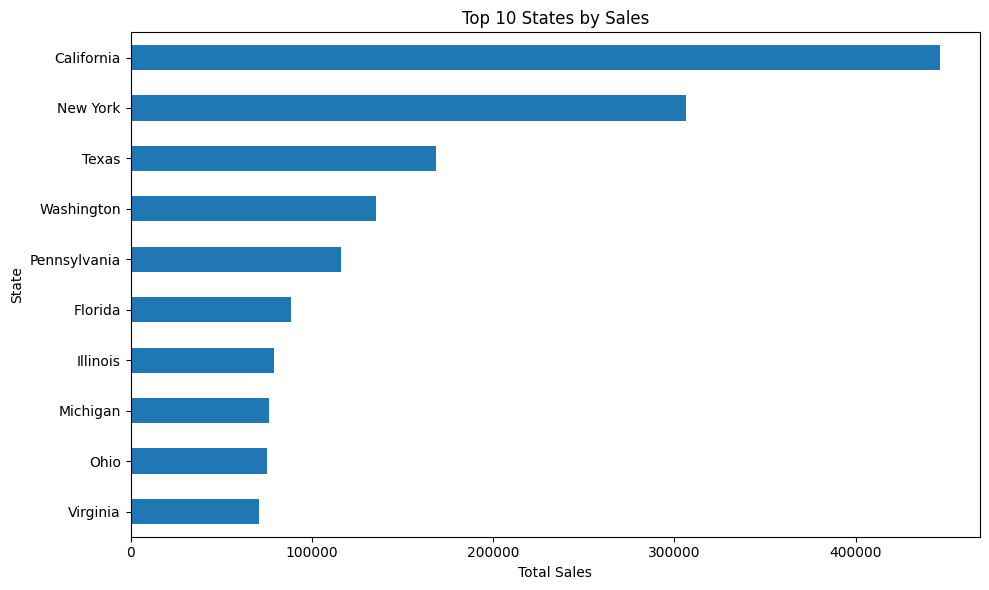

In [71]:
top_states = (
    df.groupby("State")["Sales"]
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(10, 6))

top_states.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "visualizations/top_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12.10 Visualization Summary

The visual analysis reinforces the main findings from the 37-question analysis:

- Technology is the strongest overall category.
- West generates the highest regional sales while South has the lowest.
- Technology leads across regions.
- Sales exhibit noticeable monthly seasonality.
- A relatively small share of customers does not dominate total revenue.
- A limited group of products contributes a meaningful but not overwhelming share of sales.
- Geographic sales are concentrated in a number of high-performing states.

## 13. Conclusion

This analysis answered 37 business questions about a retail superstore's sales data, covering order and sales fundamentals, category/sub-category and product performance, customer and sales concentration, customer segmentation, regional performance, time-based trends, and cross-dimensional patterns. The findings show a business with diversified category and customer revenue, a clear regional gap (South vs. the other three regions), a consistent Technology-led category preference across regions and segments, and a seasonal sales pattern peaking around September–December.

Two items are flagged for further verification rather than reported as fact: the individual top-10 product list (Question 11/12) and the above-average outlier states (Question 24) — both were computed in the original working notebook but their outputs were not captured, so they should be re-run against the source CSV before being cited.

---

## 14. Portfolio Summary

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

### Analysis Techniques
- Exploratory Data Analysis
- GroupBy Aggregation
- Customer Segmentation
- Concentration Analysis
- Geographic Analysis
- Time-Series Analysis
- Anomaly Detection
- Multi-Dimensional Analysis

### Business Focus
- Revenue performance
- Product performance
- Customer concentration
- Regional opportunities
- Seasonal sales patterns
- Business recommendations

### Project Scope

This project focuses on descriptive and exploratory analysis. It does not include machine learning, forecasting, regression, clustering, or predictive modeling.